<a href="https://colab.research.google.com/github/AvisarBhandari/Ml/blob/main/5_pytorch_custom_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [2]:
import zipfile
import requests
from pathlib import Path

# Set path for the folder
data_path = Path("data/")
image_path = data_path/"pizza_steak_sushi"
# If the image folder doesn't exist, download it and prepare it..
if image_path.is_dir():
  print(f"{image_path} directory exist")
else:
  print(f"{image_path} directory does not exist making new one...")
  image_path.mkdir(parents=True,
                   exist_ok=True)
# dwonloading zip data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/AvisarBhandari/Ml/raw/main/Custom%20data/data/pizza_steak_sushi_20_percent.zip")
  print("Downloading data ...")
  f.write(request.content)
# Unzipping data
with zipfile.ZipFile(data_path /"pizza_steak_sushi.zip","r") as zip_ref:
  print("Unzipping data ...")
  zip_ref.extractall(image_path)

data/pizza_steak_sushi directory does not exist making new one...
Unzipping data ...


In [3]:
import os
def walk_through_dir(dir_path):
  """Walks through dir_path returning its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [4]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 58 images in 'data/pizza_steak_sushi/test/steak'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 150 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 154 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 146 images in 'data/pizza_steak_sushi/train/steak'.


In [5]:
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir , test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

Random image path: data/pizza_steak_sushi/train/pizza/618348.jpg
Image class: pizza
Image height: 512
Image width: 512


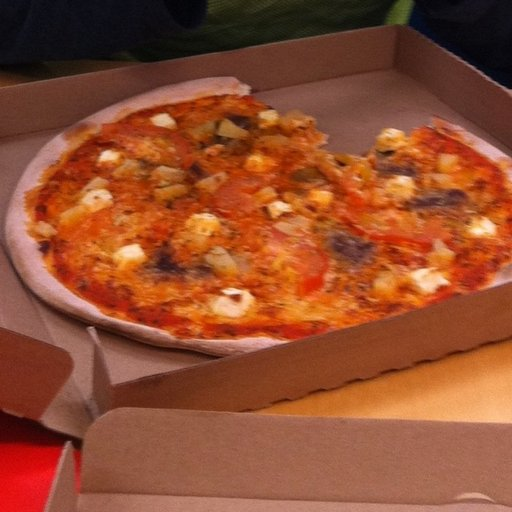

In [6]:
import random
from PIL import Image

# 1 Get Image Path
image_path_list = list(image_path.glob("*/*/*.jpg"))
# 2 pick random image
random_image_path = random.choice(image_path_list)
# 3 Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem
# 4 open the image
img = Image.open(random_image_path)
# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

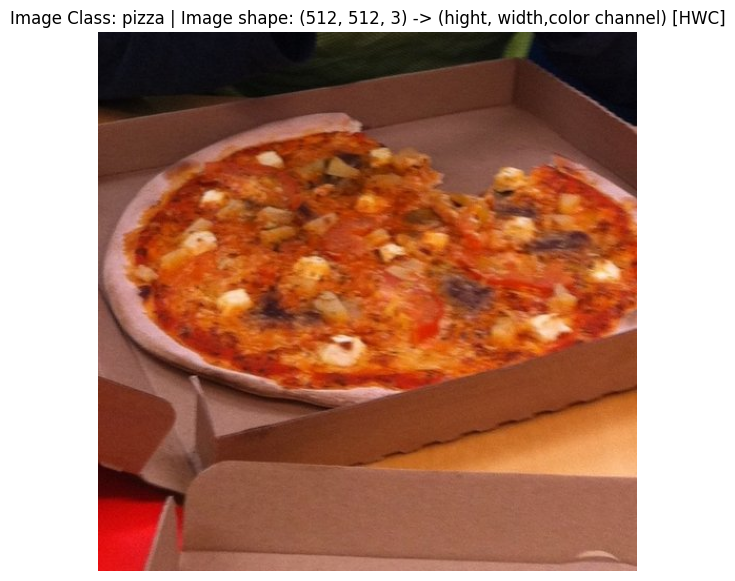

In [7]:
import numpy as np
import matplotlib.pyplot as plt
image_as_array = np.asarray(img)
plt.figure(figsize=(10,7))
plt.title(f"Image Class: {image_class} | Image shape: {image_as_array.shape} -> (hight, width,color channel) [HWC]")
plt.imshow(image_as_array)
plt.axis(False)

## Transforming data


In [8]:
import torch
from torch.utils.data import dataloader
from torchvision import transforms , datasets
# transform for image
data_transfor = transforms.Compose([
    # resize image
    transforms.Resize(size=(64,64)),
    # flip the image randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    # transfro to tensor
    transforms.ToTensor()
])

In [9]:
data_transfor(img).shape

torch.Size([3, 64, 64])

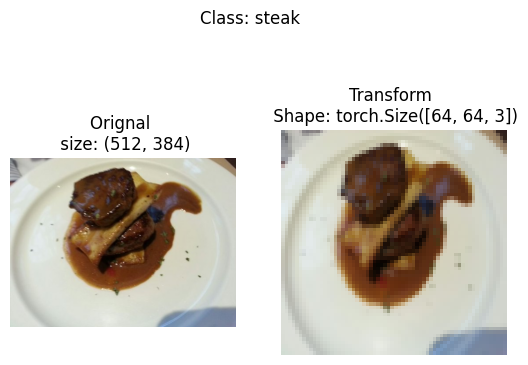

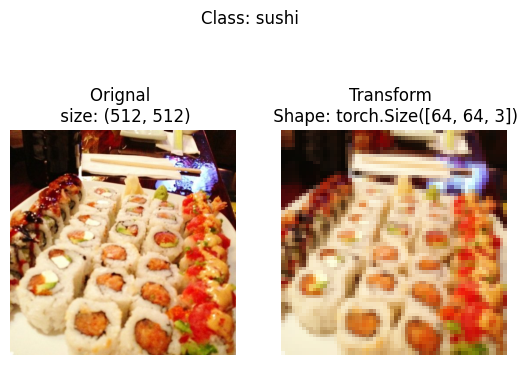

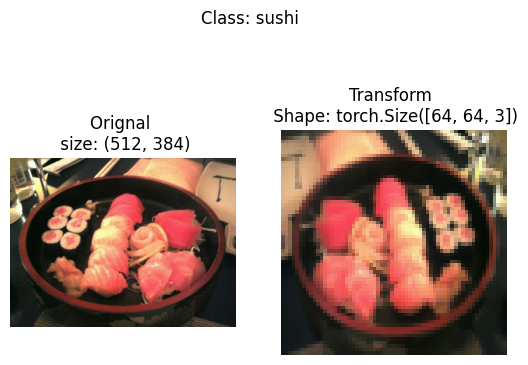

In [10]:
def plot_transformed_image(image_path:list, transform, n=3, seed = None):
  """
  Selects random images from a path of images and loads/transforms
  them then plots the original vs the transformed version.
  """
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_path,k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1, ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Orignal \n size: {f.size}")
      ax[0].axis(False)
      # Transform and plot target image
      transform_image = transform(f).permute(1,2,0) # change shape for matplotlib (C, H, W) -> (H, W, C)
      ax[1].imshow(transform_image)
      ax[1].set_title(f"Transform \n Shape: {transform_image.shape}")
      ax[1].axis(False)

      fig.suptitle(f"Class: {image_path.parent.stem}")

plot_transformed_image(image_path=image_path_list, transform=data_transfor,seed=42)

## Option 1: Loading image data using `ImageFolder`


In [11]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transfor, # transform the image
                                  target_transform=None # transfrom the label
                                  )
test_data = datasets.ImageFolder(root=test_dir,transform=data_transfor)
train_data , test_data

(Dataset ImageFolder
     Number of datapoints: 450
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 150
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [12]:
train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [13]:
# Get class name
class_name = train_data.classes
class_name

['pizza', 'steak', 'sushi']

In [14]:
# Get class names as dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [15]:
len(train_data), len(test_data)

(450, 150)

In [16]:
test_data.samples[0], test_data.targets[0]

(('data/pizza_steak_sushi/test/pizza/1001116.jpg', 0), 0)

In [17]:
# Index on the train_data Dataset to get a single image and label
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


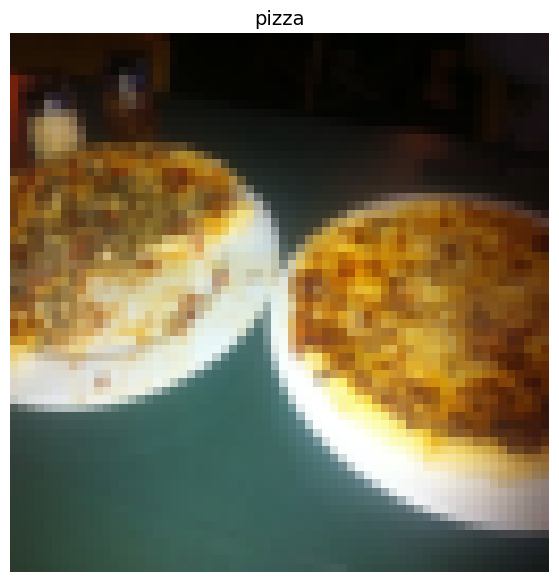

In [18]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_name[label], fontsize=14);

In [19]:
import os
os.cpu_count()

2

Turn loaded images into `DataLoader`'s

In [20]:
from torch.utils.data import DataLoader
BATCH_SIZE = 1
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=1, # how many subprocesses to use for data loading? (higher = more)
                              shuffle=True
                              )
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=1,
                             shuffle=True)
test_dataloader,train_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7fd5ae6820f0>,
 <torch.utils.data.dataloader.DataLoader at 0x7fd5ae9b9850>)

In [21]:
len(train_dataloader) , len(test_dataloader)

(450, 150)

In [22]:
img , label  = next(iter(train_dataloader))
print(f"Image Shape: {img.shape} -> [batch_size, color_channelsr, hight, width]")
print(f"Label Shaep: {label.shape}")

Image Shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channelsr, hight, width]
Label Shaep: torch.Size([1])


### Option 2: Loading Image Data with a Custom `Dataset`

In [23]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List


In [24]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [25]:
# setup target directory
target_directory = train_dir
print(f"Target dir: {target_directory}")

# Get class name from target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target dir: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [26]:
list(os.scandir(target_directory)) , os.scandir(target_directory)

([<DirEntry 'sushi'>, <DirEntry 'pizza'>, <DirEntry 'steak'>],
 <posix.ScandirIterator at 0x7fd5ae558130>)

In [27]:
def find_classes(directory:str) -> Tuple[List[int],Dict[str,int]]:
  """ Find Class folder name in the target directory """
  # Get the class name by scanning the target directory
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir)

  # error if class name not found
  if not classes:
    raise FileNotFoundError(f"File not find in {directory}")

  # dictionary if index label
  class_to_idx = {class_name:i for i ,class_name in enumerate(classes)}

  return classes , class_to_idx

In [28]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

## Create a custom `Dataset` to replicate `ImageFolder`

To create our own custom dataset, we want to:

1. Subclass `torch.utils.data.Dataset`
2. Init our subclass with a target directory (the directory we'd like to get data from) as well as a transform if we'd like to transform our data.
3. Create several attributes:
  * paths - paths of our images
  * transform - the transform we'd like to use
  * classes - a list of the target classes
  * class_to_idx - a dict of the target classes mapped to integer labels
4. Create a function to `load_images()`, this function will open an image
5. Overwrite the `__len__()` method to return the length of our dataset
6. Overwrite the `__getitem__()` method to return a given sample when passed an index

In [29]:
# make custom dataset class
from torch.utils.data import Dataset
# subclass "torch.utils.data.dataset"
class ImageFolderCustom(Dataset):
  # initialize our custom dataset
  def __init__(self , targ_dir:str , transform=None):
    # Get all image path
    self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
    # setup transform
    self.transform = transform
    # classes and class_to_idx attributes
    self.classes , self.class_to_idx = find_classes(targ_dir)

    # function to load image
  def load_image(self , index: int) -> Image.Image:
    """ Open image via path and return it """
    image_path = self.paths[index]
    return Image.open(image_path)
      # operwrite __len__()
  def __len__(self) -> int:
    return len(self.paths)
  def __getitem__(self,index:int) -> Tuple[torch.Tensor , int]:
    img = self.load_image(index)
    class_name = self.paths[index].parent.name
    class_idx = self.class_to_idx[class_name]

    # transform if necessey
    if self.transform:
      return self.transform(img) , class_idx
    else:
      return img , class_idx


In [30]:
# create transform
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])
test_transfort = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [31]:
# test custome ImageFolderCustom
train_data_custom = ImageFolderCustom(targ_dir=train_dir,transform=train_transform)
test_data_custom = ImageFolderCustom(targ_dir=test_dir,transform=test_transfort)

In [32]:
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7fd5ae509280>,
 <__main__.ImageFolderCustom at 0x7fd5aea5fdd0>)

In [33]:
len(train_data), len(train_data_custom)

(450, 450)

In [34]:
len(test_data), len(test_data_custom)

(150, 150)

In [35]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [36]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [37]:
train_data_custom[1]

(tensor([[[0.5882, 0.5961, 0.6039,  ..., 0.5098, 0.5098, 0.5137],
          [0.6039, 0.6039, 0.5922,  ..., 0.5176, 0.5451, 0.5451],
          [0.6078, 0.6078, 0.5961,  ..., 0.4627, 0.5216, 0.5333],
          ...,
          [0.5451, 0.5569, 0.5529,  ..., 0.5647, 0.5647, 0.5569],
          [0.5412, 0.5608, 0.5647,  ..., 0.5686, 0.5608, 0.5451],
          [0.5255, 0.5529, 0.5608,  ..., 0.5490, 0.5216, 0.4627]],
 
         [[0.3294, 0.3373, 0.3373,  ..., 0.2627, 0.2667, 0.2667],
          [0.3451, 0.3412, 0.3412,  ..., 0.2471, 0.2627, 0.2706],
          [0.3608, 0.3608, 0.3490,  ..., 0.1647, 0.2157, 0.2431],
          ...,
          [0.3294, 0.3412, 0.3490,  ..., 0.4157, 0.4078, 0.4157],
          [0.3294, 0.3333, 0.3412,  ..., 0.4157, 0.4118, 0.4000],
          [0.3176, 0.3255, 0.3333,  ..., 0.3961, 0.3725, 0.3216]],
 
         [[0.1216, 0.1294, 0.1373,  ..., 0.2824, 0.2941, 0.2980],
          [0.1255, 0.1490, 0.1451,  ..., 0.2745, 0.3137, 0.3176],
          [0.1216, 0.1412, 0.1490,  ...,

In [38]:
# Quility between ImageFolder and custom ImageFolder
print(train_data_custom.classes == train_data.classes)
print(test_data_custom.classes == test_data.classes)

True
True


In [39]:
# function to display random dataset
def display_random_image(dataset:torch.utils.data.Dataset,classes:list[str],n:int = 10, display_shape:bool = True , seed:int =None):
  # Adjust display if n is too high
  if n > 10:
    n = 10
    display_shape = False
    print(f"For display purposes n should not be grater the 10 , setting n as 10 and removing shape display")
    # set seed
  if seed:
    random.seed(seed)
  # Get random sample
  random_sample_idx = random.sample(range(len(dataset)) , k=n)
  # setup plot
  plt.figure(figsize=(16,8))
  # loop through and plot image
  for i, targ_sample in enumerate(random_sample_idx):
    targ_image , targ_label = dataset[targ_sample][0], dataset[targ_sample][1]
    # Adjust tensor dimensions for plotting
    targ_image_adjust = targ_image.permute(1,2,0) # [color_channels, height, width] -> [height, width, color_channels]
    # Plot adjusted samples
    if i<5:
      plt.subplot(1,n,i+1)
    else:
      plt.subplot(2,n,i-4)

    plt.imshow(targ_image_adjust)
    plt.axis("off")
    if classes:
      title = f"Classes: {classes[targ_label]}"
      if display_shape:
        title = title+ f"\n Shape: {targ_image_adjust.shape}"
    plt.title(title)



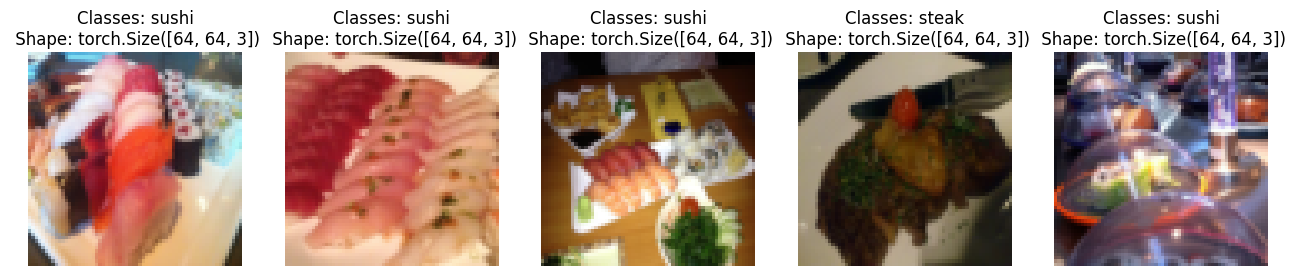

In [40]:
# Display random images from the ImageFolder created Dataset
display_random_image(dataset=train_data_custom,classes=class_name,n=5 )

For display purposes n should not be grater the 10 , setting n as 10 and removing shape display


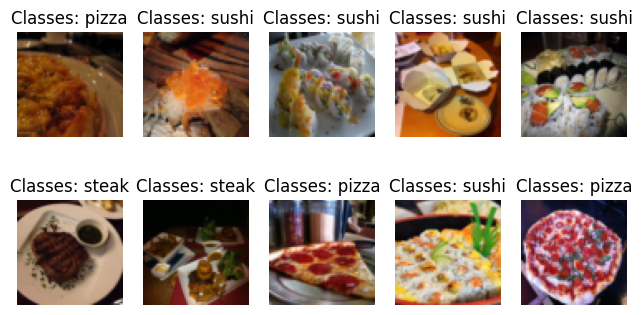

In [41]:
display_random_image(dataset=train_data_custom,classes=class_name,n=50 )

In [42]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     num_workers=NUM_WORKERS)
test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)
train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7fd5ae34a2a0>,
 <torch.utils.data.dataloader.DataLoader at 0x7fd5ae76c920>)

In [43]:
img_custom, label_custom = next(iter(train_dataloader_custom))

img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

###  Other forms of transforms (data augmentation)

In [45]:
# https://docs.pytorch.org/vision/stable/auto_examples/transforms/plot_transforms_illustrations.html#trivialaugmentwide
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize(size=(224,225)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])
test_transfort = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

In [46]:
image_path

PosixPath('data/pizza_steak_sushi')

In [51]:
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:5]

[PosixPath('data/pizza_steak_sushi/test/sushi/3365273.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3494950.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/389730.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/128616.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2378406.jpg')]

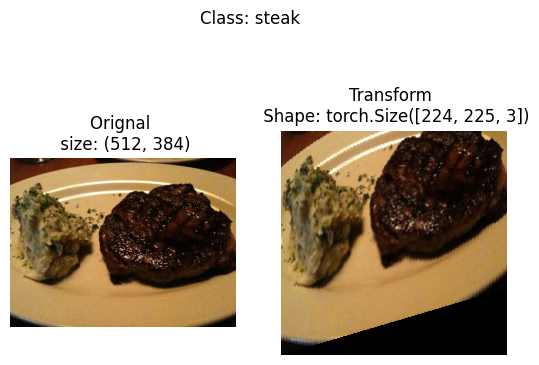

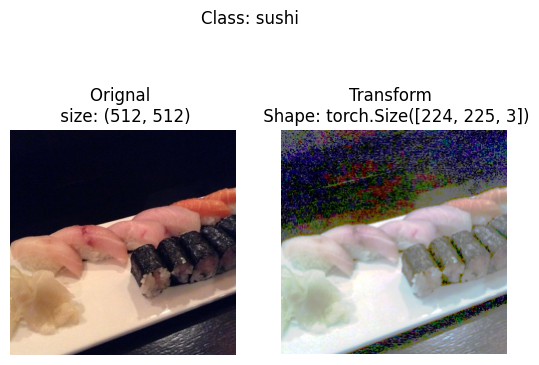

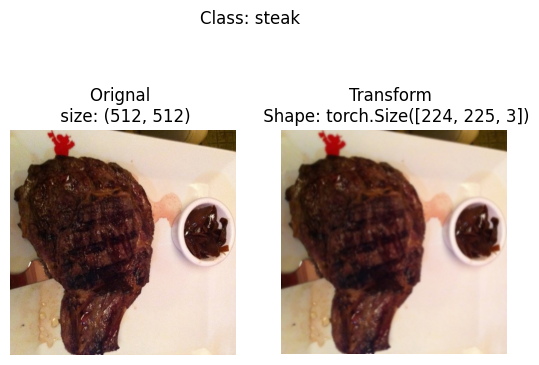

In [53]:
plot_transformed_image(
    image_path=image_path_list,
    transform=train_transform,
    n=3,
    seed=None
)